In [1]:
import os
os.environ["PATH"] = os.path.expanduser("~/texlive/bin/x86_64-linux") + ":" + os.environ["PATH"]

import numpy as np
import matplotlib.pyplot as plt
import csiborgtools
import scienceplots
from h5py import File

from hmf import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_rusty)

/mnt/home/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pickle

r_all = []
cos_theta_all = []

with File("/mnt/home/rstiskalek/ceph/graps4science/Quijote_Fiducial_rockstar_4_ALL.hdf5", 'r') as f:
    main_grp = f["fiducial"]

    keys = list(main_grp.keys())
    for name in tqdm(keys):
        grp = main_grp[name]
        X = np.vstack([grp[k][...] for k in "XYZ"]).T - 500
        r = np.linalg.norm(X, axis=1)
        logM = np.log10(grp["Mvir"][...])

        m = (r < 500) & (logM > 13.75)
        X = X[m]
        r = r[m]

        mask = r < 100
        r_sel = r[mask]
        cos_theta_sel = X[mask, 2] / r_sel

        r_all.append(r_sel)
        cos_theta_all.append(cos_theta_sel)

# Save to pickle
with open("quijote_r_cos_theta.pkl", "wb") as f:
    pickle.dump({"r": r_all, "cos_theta": cos_theta_all}, f)

    
    

In [2]:
import pickle

with open("quijote_r_cos_theta.pkl", "rb") as f:
    data = pickle.load(f)

r_all = data["r"]
cos_theta_all = data["cos_theta"]

In [3]:
# Apply r cut to all simulations
r_cut = []
cos_theta_cut = []

for r, cos in zip(r_all, cos_theta_all):
    mask = (r > 25) & (r < 50)
    r_cut.append(r[mask])
    cos_theta_cut.append(cos[mask])

In [5]:
import numpy as np
from scipy.stats import wasserstein_distance
from tqdm import trange

n = len(r_cut)
D = np.full((n, n), np.nan)

print("Computing pairwise Wasserstein distances:")

for i in trange(n, desc="Sim i"):
    a = cos_theta_cut[i]

    if a.size == 0:
        continue

    for j in range(i + 1, n):
        b = cos_theta_cut[j]

        if b.size == 0:
            print(f"  Skipping pair ({i}, {j}): one is empty.")
            continue

        d = wasserstein_distance(a, b)
        D[i, j] = D[j, i] = d

print("Done.")

np.save("wasserstein_distances.npy", D)

Computing pairwise Wasserstein distances:


Sim i: 100%|██████████| 7999/7999 [11:17<00:00, 11.80it/s] 


Done.


In [7]:
D_diag = D[~np.eye(D.shape[0], dtype=bool)]

In [63]:
def load_2mpp(filename="2MPP.txt"):
    from astropy.cosmology import FlatLambdaCDM

    cosmo = FlatLambdaCDM(H0=100, Om0=0.306)
    data = np.loadtxt(filename)

    ra = data[:, 1]  # radians
    dec = data[:, 2]  # radians
    zo = data[:, 3]

    d = cosmo.comoving_distance(zo).value 
    ra = np.rad2deg(ra)
    dec = np.rad2deg(dec)

    return d, ra, dec

    # X = np.vstack([comoving_dist, np.rad2deg(ra), np.rad2deg(dec)]).T
    # return csiborgtools.radec_to_cartesian(X)


In [ ]:
from astropy.cosmology import FlatLambdaCDM

cosmo = FlatLambdaCDM(H0=100, Om0=0.306)

cosmo.comoving_distance([0.01, 0.02])

In [ ]:
85 * 0.7

In [ ]:
# f = "/mnt/home/rstiskalek/ceph/CSiBORG/2MPP_INNER_N128_DES_V2/resimulations/step_4/output/groups_123/fof_subhalo_tab_123.hdf5"
# reader = csiborgtools.read.CSiBORGCatalogue(0, 0, paths, fpath_override=f, boxsize=340.5)
reader = csiborgtools.read.CSiBORGCatalogue(0, 130, paths, )

In [12]:
from tqdm import trange

catalogs = []

for nsim in trange(50):
    reader = csiborgtools.read.CSiBORGCatalogue(nsim, 130, paths, verbose=False)
    M = reader["totmass"]
    r, SGL, SGB = reader["supergalactic_pos"].T
    _, ell, b = reader["galactic_pos"].T

    catalogs.append({
        "M": M,
        "r": r,
        "SGL": SGL,
        "SGB": SGB,
        "ell": ell,
        "b": b,
    })

100%|██████████| 50/50 [04:56<00:00,  5.92s/it]


In [94]:
filtered_catalogs = []

rmin = 0
rmax = 100

for cat in catalogs:
    M = cat["M"]
    r = cat["r"]
    b = cat["b"]

    m = (M > 1e14) & (r > rmin) & (r < rmax) & (np.abs(b) > 10)
    print(f"Filtered {len(cat['M'])} -> {len(cat['M'][m])}")

    filtered_catalogs.append({key: np.copy(val[m]) for key, val in cat.items()})


Filtered 551830 -> 90
Filtered 552281 -> 100
Filtered 553876 -> 99
Filtered 553178 -> 98
Filtered 553404 -> 104
Filtered 552922 -> 94
Filtered 548498 -> 109
Filtered 552895 -> 102
Filtered 551272 -> 94
Filtered 552826 -> 98
Filtered 551706 -> 103
Filtered 549048 -> 99
Filtered 551913 -> 105
Filtered 551004 -> 118
Filtered 553197 -> 106
Filtered 550634 -> 106
Filtered 551377 -> 93
Filtered 552997 -> 102
Filtered 554613 -> 102
Filtered 552588 -> 96
Filtered 551544 -> 94
Filtered 549753 -> 98
Filtered 549798 -> 105
Filtered 552617 -> 112
Filtered 550371 -> 112
Filtered 551738 -> 100
Filtered 546750 -> 103
Filtered 551515 -> 107
Filtered 550058 -> 116
Filtered 551124 -> 100
Filtered 553689 -> 102
Filtered 549510 -> 98
Filtered 554008 -> 102
Filtered 550434 -> 108
Filtered 552592 -> 103
Filtered 548656 -> 94
Filtered 550803 -> 104
Filtered 552941 -> 108
Filtered 549675 -> 101
Filtered 552816 -> 115
Filtered 551583 -> 98
Filtered 551260 -> 100
Filtered 553795 -> 97
Filtered 552057 -> 95
Filt

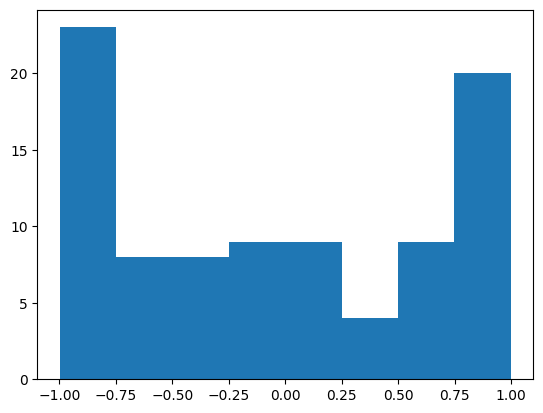

In [97]:
plt.figure()
plt.hist(np.sin(np.rad2deg(filtered_catalogs[0]["SGB"])), bins="auto", )
plt.show()

In [13]:
# filtered_catalogs = []

# rmin = 25
# rmax = 50

# for cat in catalogs:
#     M = cat["M"]
#     r = cat["r"]
#     b = cat["b"]

#     m = (M > 5.62e13) & (r > rmin) & (r < rmax) & (np.abs(b) > 10)
#     print(f"Filtered {len(cat['M'])} -> {len(cat['M'][m])}")

#     filtered_catalogs.append({key: np.copy(val[m]) for key, val in cat.items()})


import numpy as np
import pickle
from scipy.stats import wasserstein_distance

# --- Load Quijote reference data ---
with open("quijote_r_cos_theta.pkl", "rb") as f:
    data = pickle.load(f)

r_all = data["r"]
cos_theta_all = data["cos_theta"]

# Apply radial cut to Quijote data
rmin = 25
rmax = 50
cos_theta_cut = [
    cos[(r > rmin) & (r < rmax)] for cos, r in zip(cos_theta_all, r_all)
]

# --- Filter CSIBORG catalogs and compute cos_theta = sin(SGB) ---
filtered_catalogs = []
cos_theta_filtered = []

for i, cat in enumerate(catalogs):
    M = cat["M"]
    r = cat["r"]
    b = cat["b"]
    SGB = cat["SGB"]

    m = (M > 5.62e13) & (r > rmin) & (r < rmax)# & (np.abs(b) > 10)
    print(f"Filtered catalog {i}: {len(M)} → {np.count_nonzero(m)}")

    filtered = {key: np.copy(val[m]) for key, val in cat.items()}
    filtered_catalogs.append(filtered)

    # cos(theta) = sin(SGB)
    cos_theta = np.sin(np.deg2rad(filtered["SGB"]))
    cos_theta_filtered.append(cos_theta)

# --- Compute Wasserstein distances ---
D = np.full((len(cos_theta_filtered), len(cos_theta_cut)), np.nan)

for i, cos_a in enumerate(cos_theta_filtered):
    for j, cos_b in enumerate(cos_theta_cut):
        if cos_a.size == 0 or cos_b.size == 0:
            continue
        D[i, j] = wasserstein_distance(cos_a, cos_b)

# Save result
np.save("csiborg_vs_quijote_wasserstein.npy", D)

print("Done. Distance matrix shape:", D.shape)

Filtered catalog 0: 551830 → 37
Filtered catalog 1: 552281 → 29
Filtered catalog 2: 553876 → 29
Filtered catalog 3: 553178 → 28
Filtered catalog 4: 553404 → 27
Filtered catalog 5: 552922 → 38
Filtered catalog 6: 548498 → 32
Filtered catalog 7: 552895 → 30
Filtered catalog 8: 551272 → 29
Filtered catalog 9: 552826 → 28
Filtered catalog 10: 551706 → 38
Filtered catalog 11: 549048 → 28
Filtered catalog 12: 551913 → 32
Filtered catalog 13: 551004 → 31
Filtered catalog 14: 553197 → 28
Filtered catalog 15: 550634 → 35
Filtered catalog 16: 551377 → 31
Filtered catalog 17: 552997 → 25
Filtered catalog 18: 554613 → 28
Filtered catalog 19: 552588 → 32
Filtered catalog 20: 551544 → 32
Filtered catalog 21: 549753 → 35
Filtered catalog 22: 549798 → 29
Filtered catalog 23: 552617 → 26
Filtered catalog 24: 550371 → 31
Filtered catalog 25: 551738 → 32
Filtered catalog 26: 546750 → 21
Filtered catalog 27: 551515 → 26
Filtered catalog 28: 550058 → 26
Filtered catalog 29: 551124 → 27
Filtered catalog 30:

In [39]:
import numpy as np
from scipy.stats import wasserstein_distance
import pickle

# --- Load the Quijote cos_theta distributions ---
with open("quijote_r_cos_theta.pkl", "rb") as f:
    data = pickle.load(f)

r_all = data["r"]
cos_theta_all = data["cos_theta"]

# Apply radial cut
rmin = 25
rmax = 50
cos_theta_cut = [
    cos[(r > rmin) & (r < rmax)] for cos, r in zip(cos_theta_all, r_all)
]

# --- Sample and compute distances ---
n_samples = 50
n_quijote = len(cos_theta_cut)
D = np.full((n_samples, n_quijote), np.nan)

for i in range(n_samples):
    x = np.random.normal(0, 0.2, 35)

    for j, cos_q in enumerate(cos_theta_cut):
        if cos_q.size == 0:
            continue
        D[i, j] = wasserstein_distance(x, cos_q)

# Save result
np.save("random_vs_quijote_wasserstein.npy", D)

print("Done. Distance matrix shape:", D.shape)

Done. Distance matrix shape: (50, 7999)


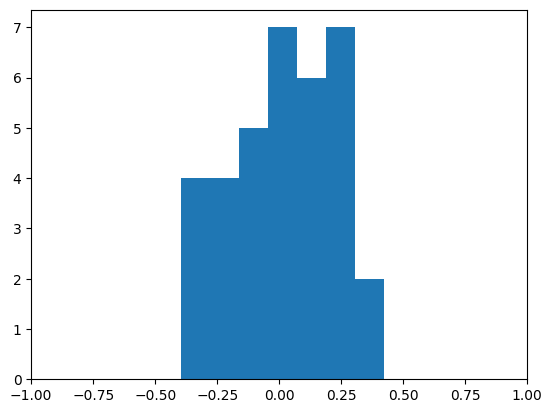

In [38]:
x = np.random.normal(0, 0.2, 35)

plt.figure()
plt.hist(x, bins="auto", )
plt.xlim(-1, 1)
plt.show()



In [40]:

D_quijote = np.load("wasserstein_distances.npy")
D_quijote = D_quijote[~np.eye(D_quijote.shape[0], dtype=bool)]

D_csiborg = np.load("csiborg_vs_quijote_wasserstein.npy")


D_random = np.load("random_vs_quijote_wasserstein.npy")


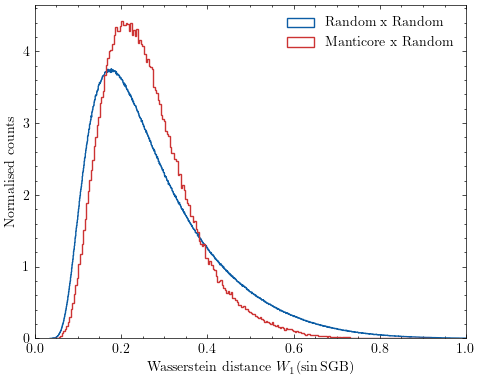

In [61]:
with plt.style.context("science"):
    plt.figure(figsize=(5, 4))
    plt.hist(D_quijote, bins="auto",  label=r"Random x Random", histtype="step", density=True)
    plt.hist(D_csiborg.reshape(-1,), bins="auto",  label="Manticore x Random", histtype="step", density=True, color=(0.8, 0.2, 0.2))

    plt.xlim(0, 1.)

    plt.xlabel(r"Wasserstein distance $W_1(\sin\mathrm{SGB})$")
    plt.ylabel(r"Normalised counts")

    plt.legend()
    plt.tight_layout()
    plt.savefig("wasserstein_distances.png", dpi=300)

    plt.show()

In [69]:
r, ra, dec = load_2mpp()
ell, b = csiborgtools.radec_to_galactic(ra, dec)
sgl, sgb = csiborgtools.radec_to_supergalactic(ra, dec)
m = (r > rmin) & (r < rmax) & (np.abs(b) > 5)
sgl = sgl[m]
sgb = sgb[m]


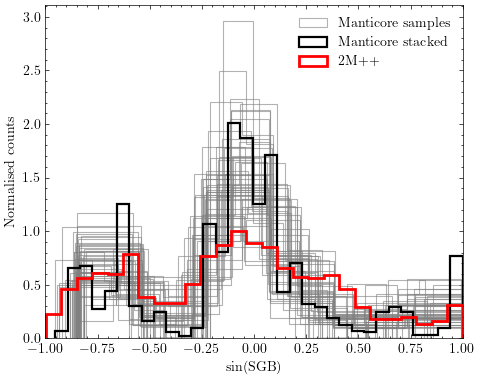

In [83]:
with plt.style.context("science"):
    plt.figure(figsize=(5, 4))

    # Plot individual density histograms
    all_sgb_sin = []

    for i, cat in enumerate(filtered_catalogs):
        sgb_sin = np.sin(np.deg2rad(cat["SGB"]))
        all_sgb_sin.append(sgb_sin)
        plt.hist(sgb_sin, bins="auto", histtype="step", linewidth=0.8,
                 color="gray", alpha=0.6, density=True, label="Manticore samples" if i == 0 else None)

    # Plot stacked total density histogram
    all_sgb_sin_flat = np.concatenate(all_sgb_sin)
    plt.hist(all_sgb_sin_flat, bins="auto", histtype="step", linewidth=1.6,
             color="black", density=True, label="Manticore stacked")

    plt.hist(np.sin(np.deg2rad(sgb)), bins="auto", histtype="step", linewidth=2.0,
             color="red", density=True, label=r"2M++")

    plt.xlim(-1, 1)

    plt.xlabel(r"$\sin(\mathrm{SGB})$")
    plt.ylabel("Normalised counts")
    plt.legend()
    plt.tight_layout()
    plt.savefig("sgb_sin_histogram.png", dpi=300)
    plt.show()

In [ ]:
plt.figure()
# plt.hist(np.log10(d["M"]), bins="auto", )
# plt.hist(d["b"], bins="auto", )
plt.hist(np.sin(np.deg2rad(d["SGB"])), bins="auto", )
# plt.xlim(-90, 90)
plt.show()